[Sectors — U.S] eval months=211, mean Q1 intersection size=14.92, mean Q1 UNION size=33.08


C:\Users\kelvi\AppData\Local\Temp\ipykernel_66924\4268904692.py:123: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)


[Industries — U.S] eval months=212, mean Q1 intersection size=14.91, mean Q1 UNION size=33.09
[Country Cross Section — America] eval months=624, mean Q1 intersection size=14.14, mean Q1 UNION size=29.21
[Factors — U.S.] eval months=259, mean Q1 intersection size=15.05, mean Q1 UNION size=32.95


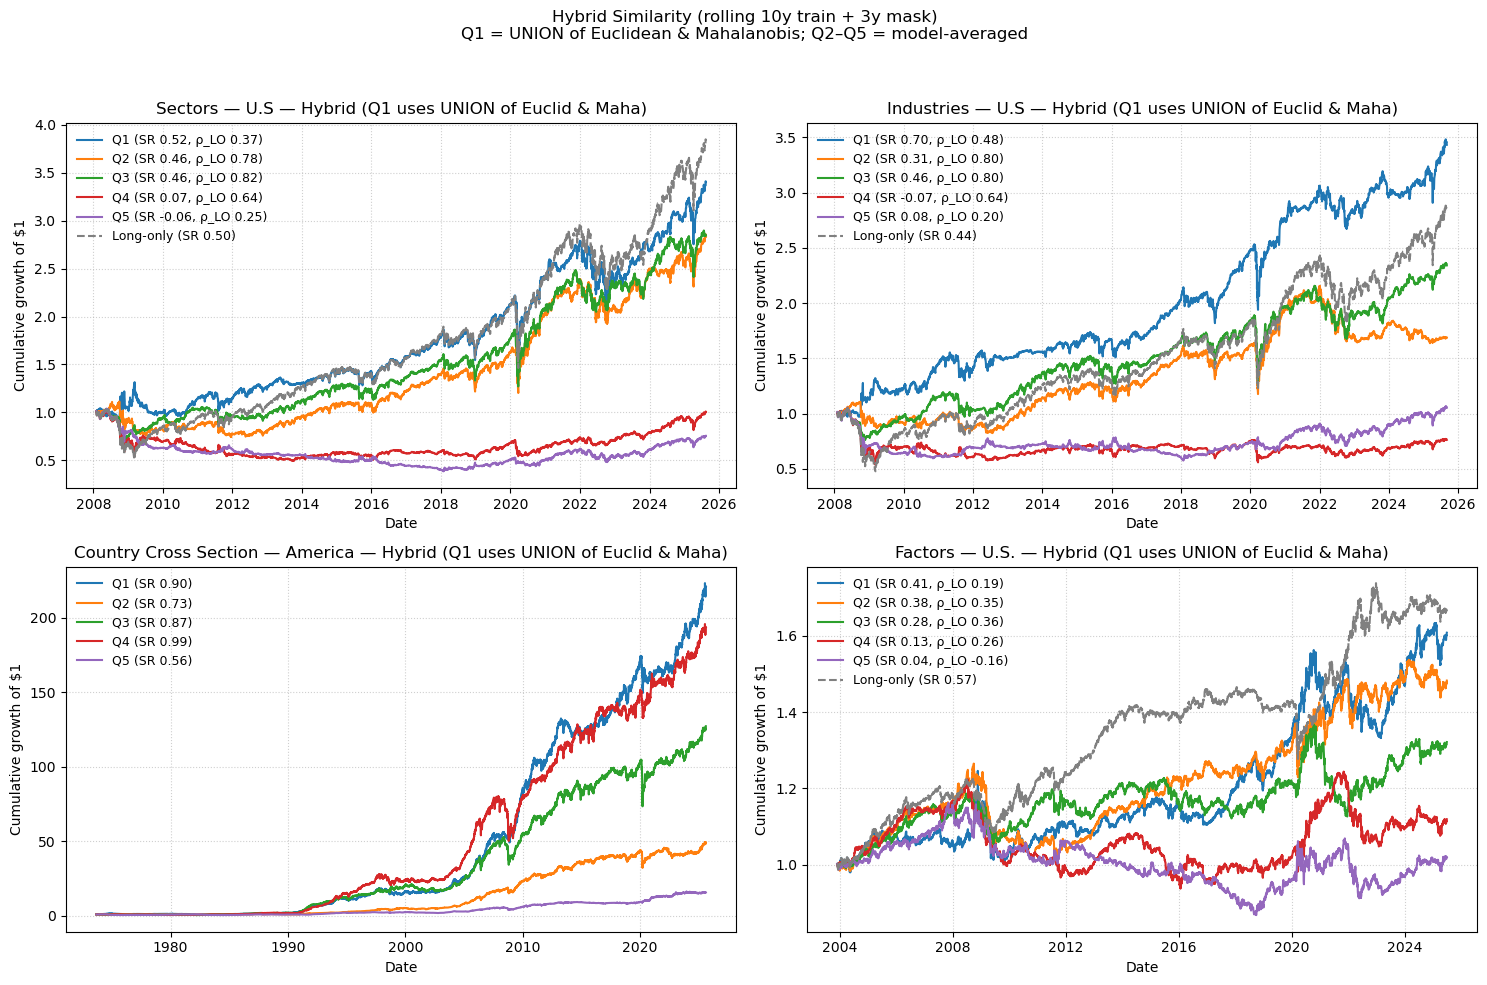

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


PATH_MACRO = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")

DATASETS = [
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Sectors\Per Region\Sector North America.xlsx"),
     "auto", "Sectors — U.S", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Developped Countries Industry.xlsx"),
     "auto", "Industries — U.S", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Americas CS Country.xlsx"),
     "auto", "Country Cross Section — America", False),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx"),
     "auto", "Factors — U.S.", True),
]

TRAIN_YEARS = 10
MASK_YEARS  = 3
MIN_COVERAGE = 1.0 

def ann_sr(s: pd.Series) -> float:
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]
    return df.corr().iloc[0,1] if not df.empty else np.nan

def make_quintiles(ordered_months):
    n = len(ordered_months)
    if n == 0: return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ordered_months[:k20]
    q5 = ordered_months[-k20:]
    mid = ordered_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}


def load_macro_states(path_macro: Path) -> pd.DataFrame:
    Z = pd.read_excel(path_macro)
    if "Month" not in Z.columns:
        for cand in ["month","MONTH","Date","Dates"]:
            if cand in Z.columns:
                Z = Z.rename(columns={cand: "Month"})
                break
    if "Month" not in Z.columns:
        raise ValueError("Macro file must have a 'Month' column (or Date/Dates).")
    Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
    Z = Z.set_index("Month").sort_index()
    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro columns found in macro file.")
    return Z[macro_cols].astype(float)

def _parse_date_column(df: pd.DataFrame) -> pd.DatetimeIndex:
    date_col = next((c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns), None)
    if date_col is None:
        raise ValueError("No date column named Dates/Date/DATE/date/dt found.")
    col = df[date_col]
    if np.issubdtype(col.dtype, np.datetime64):
        dt = pd.to_datetime(col, errors="coerce")
    else:
        as_str = col.astype(str).str.strip()
        if as_str.str.fullmatch(r"\d{8}").fillna(False).all():
            dt = pd.to_datetime(as_str, format="%Y%m%d", errors="coerce")
        else:
            dt = pd.to_datetime(col, errors="coerce")
    if dt.isna().all():
        raise ValueError("All dates failed to parse. Check the date format.")
    return dt

def load_assets_auto(path: Path, min_coverage: float = MIN_COVERAGE):

    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
    present  = [c for c in std_cols if c in df.columns]

    dt = _parse_date_column(df)
    date_col = next(c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns)
    df = df.assign(**{date_col: dt}).dropna(subset=[date_col]).set_index(date_col).sort_index()

    if len(present) >= 5:
        sample = df[present].select_dtypes(include=[np.number]).stack()
        if sample.abs().median() > 0.05:
            df[present] = df[present].astype(float) / 100.0
        else:
            df[present] = df[present].astype(float)
        assets = [c for c in present if c != "RF"]
        sec_ret_daily   = df[assets].replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0
    else:
        # Levels -> returns
        assets = [c for c in df.columns if c not in ["Dates","Date","DATE","date","dt"]
                  and pd.api.types.is_numeric_dtype(df[c])]
        if not assets:
            raise ValueError(f"No numeric asset columns found in {path.name}")
        sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

    need = max(1, int(np.ceil(min_coverage * len(assets))))
    good_months = sec_ret_monthly.notna().sum(axis=1) >= need
    sec_ret_monthly = sec_ret_monthly.loc[good_months]
    sector_months   = sec_ret_monthly.index.to_period("M")

    keep = sec_ret_daily.index.to_period("M").isin(sector_months)
    sec_ret_daily = sec_ret_daily.loc[keep]

    sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
    return sec_ret_daily, sec_ret_monthly, assets, sector_months


def euclid_distances(F_train: pd.DataFrame, x0: pd.Series) -> pd.Series:
    common = F_train.columns.intersection(x0.index)
    if len(common) == 0 or F_train.empty:
        return pd.Series(dtype=float)
    X = F_train[common].values.astype(float)
    x = x0[common].values.astype(float)
    d = np.linalg.norm(X - x[None,:], axis=1)
    return pd.Series(d, index=F_train.index).sort_values()

def mahalanobis_distances(F_train: pd.DataFrame, x0: pd.Series, ridge: float = 1e-8) -> pd.Series:
    common = F_train.columns.intersection(x0.index)
    if len(common) == 0 or F_train.shape[0] == 0:
        return pd.Series(dtype=float)
    X = F_train[common].values.astype(float)     # (n, p)
    x = x0[common].values.astype(float).reshape(1, -1)
    if X.shape[1] == 0:
        return pd.Series(dtype=float)
    Σ = np.cov(X, rowvar=False)
    Σ = np.atleast_2d(np.asarray(Σ))
    p = Σ.shape[0]
    if Σ.shape[0] != Σ.shape[1] or p != X.shape[1]:
        var = X.var(axis=0, ddof=1)
        var[var <= 0] = ridge
        Σ = np.diag(var)
        p = Σ.shape[0]
    Σ = Σ + ridge * np.eye(p)
    try:
        Σ_inv = np.linalg.inv(Σ)
    except np.linalg.LinAlgError:
        Σ_inv = np.linalg.pinv(Σ)
    diffs = X - x
    d2 = np.einsum("ij,jk,ik->i", diffs, Σ_inv, diffs)
    d = np.sqrt(np.clip(d2, 0, np.inf))
    return pd.Series(d, index=F_train.index).sort_values()


def build_quintile_series_rolling_hybrid(path: Path,
                                         train_years: int = TRAIN_YEARS,
                                         mask_years: int  = MASK_YEARS,
                                         min_coverage: float = MIN_COVERAGE):

    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets_auto(path, min_coverage=min_coverage)

    Z_all = load_macro_states(PATH_MACRO)
    Z = Z_all.reindex(sector_months).ffill()

    min_m = max(sector_months.min(), Z.index.min())
    if not isinstance(min_m, pd.Period):
        min_m = pd.Period(min_m, freq="M")
    first_eval = min_m + (train_years + mask_years) * 12
    months_bt = sector_months[(sector_months >= first_eval)]

    returns_by_q = {q: [] for q in range(1,6)}  
    q1_intersection_sizes = []
    q1_union_sizes = []

    for m in months_bt:
        tr_end   = (m - mask_years)           
        tr_start = tr_end - (train_years*12) + 1

        F_train = Z.loc[(Z.index >= tr_start) & (Z.index <= tr_end)].dropna(how="any")
        if F_train.shape[0] < 2:
            continue
        x0 = Z.loc[m].dropna()
        if x0.empty:
            continue

        dE = euclid_distances(F_train, x0)
        dM = mahalanobis_distances(F_train, x0)
        if dE.empty or dM.empty:
            continue

        buckets_E = make_quintiles(list(dE.index))
        buckets_M = make_quintiles(list(dM.index))

        next_m = m + 1
        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == next_m]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        def mu_next_over(months_set) -> pd.Series:
            if len(months_set) == 0:
                return pd.Series(0.0, index=assets)
            idx_sim_next = (pd.PeriodIndex(months_set, freq="M") + 1)
            idx_sim_next = sec_ret_monthly.index.intersection(idx_sim_next)
            if len(idx_sim_next) == 0:
                return pd.Series(0.0, index=assets)
            return sec_ret_monthly.loc[idx_sim_next, assets].mean(axis=0)

        for q in [1,2,3,4,5]:
            set_E = set(buckets_E[q])
            set_M = set(buckets_M[q])

            if q == 1:
                inter = set_E & set_M
                union = set_E | set_M
                q1_intersection_sizes.append(len(inter))
                q1_union_sizes.append(len(union))

                use_months = list(union)

                if len(use_months) > 0:
                    mu_final = mu_next_over(use_months)
                else:
                    mu_final = pd.concat(
                        [mu_next_over(buckets_E[q]), mu_next_over(buckets_M[q])],
                        axis=1
                    ).mean(axis=1)
            else:
                mu_final = pd.concat(
                    [mu_next_over(buckets_E[q]), mu_next_over(buckets_M[q])],
                    axis=1
                ).mean(axis=1)

            signs = np.sign(mu_final.fillna(0.0))
            q_daily = (Rm * signs).mean(axis=1)
            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        idx = q_series[q].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    stats = {
        "mean_Q1_intersection": float(np.nan if len(q1_intersection_sizes) == 0 else np.mean(q1_intersection_sizes)),
        "mean_Q1_union":        float(np.nan if len(q1_union_sizes) == 0 else np.mean(q1_union_sizes)),
        "count_eval_months":    int(len(q1_union_sizes))
    }

    return q_series, long_only, stats



fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()

for ax, (path, kind, title, show_lo) in zip(axes, DATASETS):
    q_series, long_only, stats = build_quintile_series_rolling_hybrid(
        path=path,
        train_years=TRAIN_YEARS,
        mask_years=MASK_YEARS,
        min_coverage=MIN_COVERAGE
    )

    for q in [1,2,3,4,5]:
        sr = ann_sr(q_series[q])
        if show_lo:
            rho = clean_corr(q_series[q], long_only)
            lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
        else:
            lbl = f"Q{q} (SR {sr:.2f})"
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

    if show_lo:
        sr_lo = ann_sr(long_only)
        ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(f"{title} — Hybrid (Q1 uses UNION of Euclid & Maha)")
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

    print(f"[{title}] eval months={stats['count_eval_months']}, "
          f"mean Q1 intersection size={stats['mean_Q1_intersection']:.2f}, "
          f"mean Q1 UNION size={stats['mean_Q1_union']:.2f}")

plt.suptitle(f"Hybrid Similarity (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask)\n"
             f"Q1 = UNION of Euclidean & Mahalanobis; Q2–Q5 = model-averaged",
             y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


C:\Users\kelvi\AppData\Local\Temp\ipykernel_66924\2025442943.py:114: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)


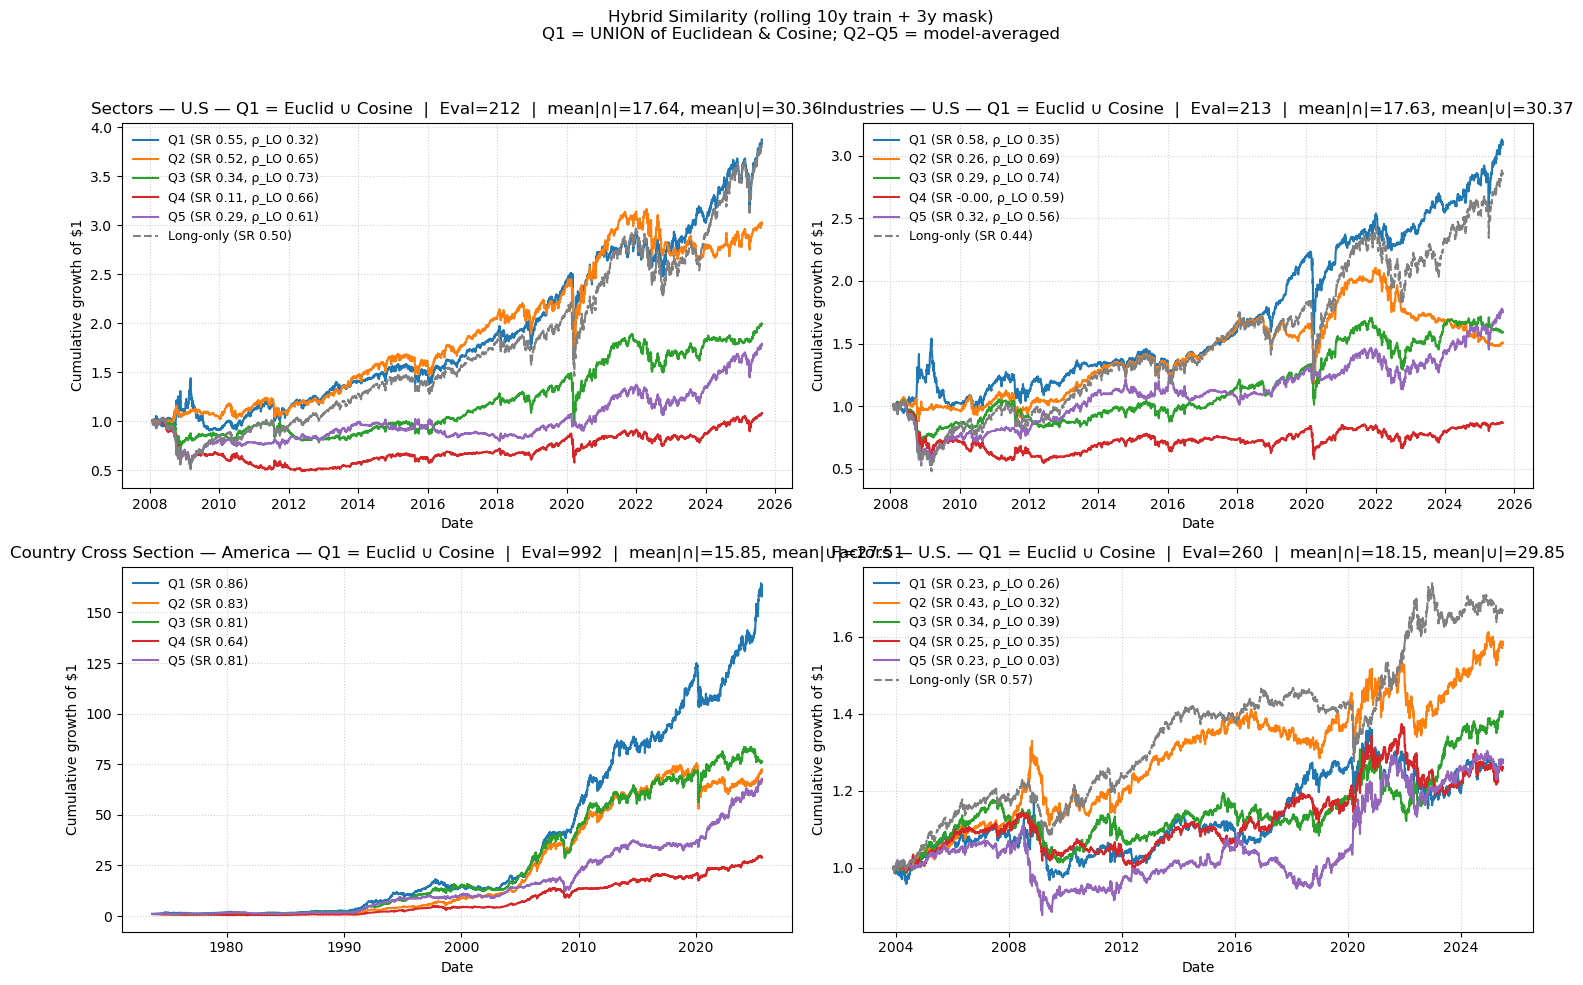

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


PATH_MACRO = Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\state_z_america.xlsx")

DATASETS = [
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Sectors\Per Region\Sector North America.xlsx"),
     "auto", "Sectors — U.S", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Industries\Developped Countries Industry.xlsx"),
     "auto", "Industries — U.S", True),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Cross Section Countries\Americas CS Country.xlsx"),
     "auto", "Country Cross Section — America", False),
    (Path(r"C:\Users\kelvi\Documents\Berkeley\Term 2\Projects\Regimes\Data\Original Reproduction\North_America_6_Factors_Daily_clean.xlsx"),
     "auto", "Factors — U.S.", True),
]

TRAIN_YEARS = 10
MASK_YEARS  = 3
MIN_COVERAGE = 1.0

def ann_sr(s: pd.Series) -> float:
    s = pd.Series(s).dropna()
    if s.empty: return np.nan
    sig = s.std()
    return (s.mean()/sig)*np.sqrt(252) if sig != 0 else np.nan

def clean_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    df = df[(df != 0).any(axis=1)]
    return df.corr().iloc[0,1] if not df.empty else np.nan

def make_quintiles(ordered_months):
    n = len(ordered_months)
    if n == 0: return {1:[],2:[],3:[],4:[],5:[]}
    k20 = max(int(0.20*n), 1)
    q1 = ordered_months[:k20]
    q5 = ordered_months[-k20:]
    mid = ordered_months[k20:-k20]
    if len(mid) >= 3:
        q2, q3, q4 = np.array_split(np.array(mid), 3)
    else:
        q2, q3, q4 = [], mid, []
    return {1:list(q1),2:list(q2),3:list(q3),4:list(q4),5:list(q5)}

def load_macro_states(path_macro: Path) -> pd.DataFrame:
    Z = pd.read_excel(path_macro)
    if "Month" not in Z.columns:
        for cand in ["month","MONTH","Date","Dates"]:
            if cand in Z.columns:
                Z = Z.rename(columns={cand: "Month"})
                break
    if "Month" not in Z.columns:
        raise ValueError("Macro file must have a 'Month' column (or Date/Dates).")
    Z["Month"] = pd.to_datetime(Z["Month"], errors="coerce").dt.to_period("M")
    Z = Z.set_index("Month").sort_index()
    macro_cols = [c for c in Z.columns if pd.api.types.is_numeric_dtype(Z[c])]
    if not macro_cols:
        raise ValueError("No numeric macro columns found in macro file.")
    return Z[macro_cols].astype(float)

def _parse_date_column(df: pd.DataFrame) -> pd.DatetimeIndex:
    date_col = next((c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns), None)
    if date_col is None:
        raise ValueError("No date column named Dates/Date/DATE/date/dt found.")
    col = df[date_col]
    if np.issubdtype(col.dtype, np.datetime64):
        dt = pd.to_datetime(col, errors="coerce")
    else:
        as_str = col.astype(str).str.strip()
        if as_str.str.fullmatch(r"\d{8}").fillna(False).all():
            dt = pd.to_datetime(as_str, format="%Y%m%d", errors="coerce")
        else:
            dt = pd.to_datetime(col, errors="coerce")
    if dt.isna().all():
        raise ValueError("All dates failed to parse. Check the date format.")
    return dt

def load_assets_auto(path: Path, min_coverage: float = MIN_COVERAGE):
    df = pd.read_excel(path)
    df.columns = [c.strip() for c in df.columns]
    std_cols = ["Mkt-RF","SMB","HML","RMW","CMA","Mom","RF"]
    present  = [c for c in std_cols if c in df.columns]

    dt = _parse_date_column(df)
    date_col = next(c for c in ["Dates", "Date", "DATE", "date", "dt"] if c in df.columns)
    df = df.assign(**{date_col: dt}).dropna(subset=[date_col]).set_index(date_col).sort_index()

    if len(present) >= 5:
        sample = df[present].select_dtypes(include=[np.number]).stack()
        if sample.abs().median() > 0.05:
            df[present] = df[present].astype(float) / 100.0
        else:
            df[present] = df[present].astype(float)
        assets = [c for c in present if c != "RF"]
        sec_ret_daily   = df[assets].replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0
    else:
        assets = [c for c in df.columns if c not in ["Dates","Date","DATE","date","dt"]
                  and pd.api.types.is_numeric_dtype(df[c])]
        if not assets:
            raise ValueError(f"No numeric asset columns found in {path.name}")
        sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)
        sec_ret_monthly = (1.0 + sec_ret_daily).resample("ME").prod() - 1.0

    need = max(1, int(np.ceil(min_coverage * len(assets))))
    good_months = sec_ret_monthly.notna().sum(axis=1) >= need
    sec_ret_monthly = sec_ret_monthly.loc[good_months]
    sector_months   = sec_ret_monthly.index.to_period("M")

    keep = sec_ret_daily.index.to_period("M").isin(sector_months)
    sec_ret_daily = sec_ret_daily.loc[keep]

    sec_ret_monthly.index = sec_ret_monthly.index.to_period("M")
    return sec_ret_daily, sec_ret_monthly, assets, sector_months

def euclid_distances(F_train: pd.DataFrame, x0: pd.Series) -> pd.Series:
    common = F_train.columns.intersection(x0.index)
    if len(common) == 0 or F_train.empty:
        return pd.Series(dtype=float)
    X = F_train[common].values.astype(float)
    x = x0[common].values.astype(float)
    d = np.linalg.norm(X - x[None,:], axis=1)
    return pd.Series(d, index=F_train.index).sort_values()

def cosine_distances(F_train: pd.DataFrame, x0: pd.Series, eps: float = 1e-12) -> pd.Series:

    common = F_train.columns.intersection(x0.index)
    if len(common) == 0 or F_train.empty:
        return pd.Series(dtype=float)
    X = F_train[common].values.astype(float)         # (n, p)
    x = x0[common].values.astype(float).reshape(1,-1) # (1, p)

    # Replace NaNs by column means within training (safe because we dropped NA rows)
    # (Optional: since F_train.dropna used, X should be clean already.)
    x_norm = np.sqrt((x * x).sum(axis=1)) + eps
    X_norm = np.sqrt((X * X).sum(axis=1)) + eps
    cos_sim = (X @ x.T).ravel() / (X_norm * x_norm[0])
    cos_dist = 1.0 - np.clip(cos_sim, -1.0, 1.0)
    return pd.Series(cos_dist, index=F_train.index).sort_values()


def build_quintile_series_rolling_union_pair(path: Path,
                                             train_years: int = TRAIN_YEARS,
                                             mask_years: int  = MASK_YEARS,
                                             min_coverage: float = MIN_COVERAGE):
    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets_auto(path, min_coverage=min_coverage)

    Z_all = load_macro_states(PATH_MACRO)
    Z = Z_all.reindex(sector_months).ffill()

    min_m = max(sector_months.min(), Z.index.min())
    if not isinstance(min_m, pd.Period):
        min_m = pd.Period(min_m, freq="M")
    first_eval = min_m + (train_years + mask_years) * 12
    months_bt = sector_months[(sector_months >= first_eval)]

    returns_by_q = {q: [] for q in range(1,6)}
    q1_inter_sizes, q1_union_sizes = [], []

    for m in months_bt:
        tr_end   = (m - mask_years)
        tr_start = tr_end - (train_years*12) + 1

        F_train = Z.loc[(Z.index >= tr_start) & (Z.index <= tr_end)].dropna(how="any")
        if F_train.shape[0] < 2:
            continue
        x0 = Z.loc[m].dropna()
        if x0.empty:
            continue

        dE = euclid_distances(F_train, x0)     
        dC = cosine_distances(F_train, x0)     
        if dE.empty or dC.empty:
            continue

        buckets_E = make_quintiles(list(dE.index))
        buckets_C = make_quintiles(list(dC.index))

        set_E, set_C = set(buckets_E[1]), set(buckets_C[1])
        inter = set_E & set_C
        union = set_E | set_C
        q1_inter_sizes.append(len(inter))
        q1_union_sizes.append(len(union))

        next_m = m + 1
        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == next_m]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        def mu_next_over(months_set) -> pd.Series:
            if len(months_set) == 0:
                return pd.Series(0.0, index=assets)
            idx_sim_next = (pd.PeriodIndex(list(months_set), freq="M") + 1)
            idx_sim_next = sec_ret_monthly.index.intersection(idx_sim_next)
            if len(idx_sim_next) == 0:
                return pd.Series(0.0, index=assets)
            return sec_ret_monthly.loc[idx_sim_next, assets].mean(axis=0)

        for q in [1,2,3,4,5]:
            setE = set(buckets_E[q])
            setC = set(buckets_C[q])

            if q == 1:
                months_sel = setE | setC
                mu_final = mu_next_over(months_sel)
            else:
                mu_final = pd.concat([mu_next_over(setE), mu_next_over(setC)], axis=1).mean(axis=1)

            signs = np.sign(mu_final.fillna(0.0))
            q_daily = (Rm * signs).mean(axis=1)
            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        idx = q_series[q].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    stats = {
        "eval_months": len(months_bt),
        "mean_Q1_intersection": float(np.mean(q1_inter_sizes)) if q1_inter_sizes else np.nan,
        "mean_Q1_union": float(np.mean(q1_union_sizes)) if q1_union_sizes else np.nan,
    }
    return q_series, long_only, stats

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()

for ax, (path, kind, title, show_lo) in zip(axes, DATASETS):
    q_series, long_only, stats = build_quintile_series_rolling_union_pair(
        path=path,
        train_years=TRAIN_YEARS,
        mask_years=MASK_YEARS,
        min_coverage=MIN_COVERAGE
    )

    for q in [1,2,3,4,5]:
        sr = ann_sr(q_series[q])
        if show_lo:
            rho = clean_corr(q_series[q], long_only)
            lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
        else:
            lbl = f"Q{q} (SR {sr:.2f})"
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

    if show_lo:
        sr_lo = ann_sr(long_only)
        ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(f"{title} — Q1 = Euclid ∪ Cosine  |  Eval={stats['eval_months']}  |  "
                 f"mean|∩|={stats['mean_Q1_intersection']:.2f}, mean|∪|={stats['mean_Q1_union']:.2f}")
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

plt.suptitle(f"Hybrid Similarity (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask)\n"
             f"Q1 = UNION of Euclidean & Cosine; Q2–Q5 = model-averaged",
             y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


C:\Users\kelvi\AppData\Local\Temp\ipykernel_66924\2025442943.py:114: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sec_ret_daily   = df[assets].pct_change().replace([np.inf,-np.inf], np.nan).dropna(how="all").clip(-0.8, 0.8)


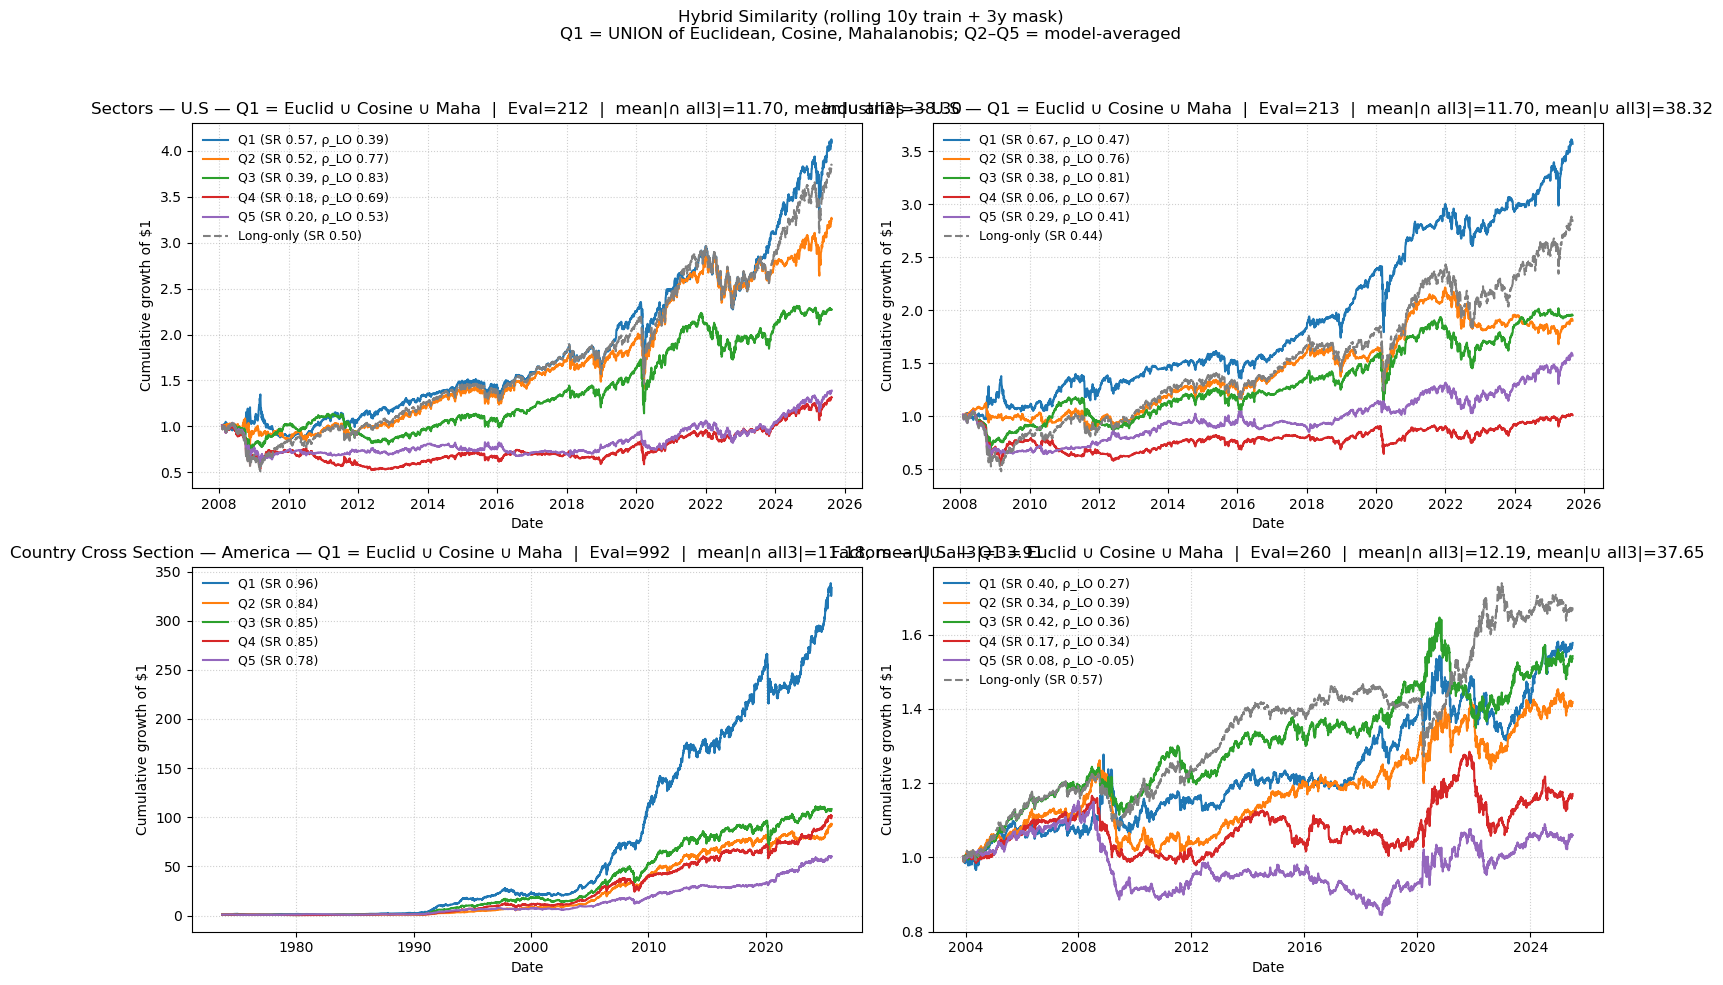

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def mahalanobis_distances(F_train: pd.DataFrame, x0: pd.Series, ridge: float = 1e-8) -> pd.Series:
    common = F_train.columns.intersection(x0.index)
    if len(common) == 0 or F_train.shape[0] == 0:
        return pd.Series(dtype=float)
    X = F_train[common].values.astype(float)
    x = x0[common].values.astype(float).reshape(1, -1)
    if X.shape[1] == 0:
        return pd.Series(dtype=float)
    Σ = np.cov(X, rowvar=False)
    Σ = np.atleast_2d(np.asarray(Σ))
    p = Σ.shape[0]
    if Σ.shape[0] != Σ.shape[1] or p != X.shape[1]:
        var = X.var(axis=0, ddof=1)
        var[var <= 0] = ridge
        Σ = np.diag(var)
        p = Σ.shape[0]
    Σ = Σ + ridge * np.eye(p)
    try:
        Σ_inv = np.linalg.inv(Σ)
    except np.linalg.LinAlgError:
        Σ_inv = np.linalg.pinv(Σ)
    diffs = X - x
    d2 = np.einsum("ij,jk,ik->i", diffs, Σ_inv, diffs)
    d = np.sqrt(np.clip(d2, 0, np.inf))
    return pd.Series(d, index=F_train.index).sort_values()

def build_quintile_series_rolling_union_trio(path: Path,
                                             train_years: int = TRAIN_YEARS,
                                             mask_years: int  = MASK_YEARS,
                                             min_coverage: float = MIN_COVERAGE):
    sec_ret_daily, sec_ret_monthly, assets, sector_months = load_assets_auto(path, min_coverage=min_coverage)

    Z_all = load_macro_states(PATH_MACRO)
    Z = Z_all.reindex(sector_months).ffill()

    min_m = max(sector_months.min(), Z.index.min())
    if not isinstance(min_m, pd.Period):
        min_m = pd.Period(min_m, freq="M")
    first_eval = min_m + (train_years + mask_years) * 12
    months_bt = sector_months[(sector_months >= first_eval)]

    returns_by_q = {q: [] for q in range(1,6)}
    q1_inter_all_sizes, q1_union_all_sizes = [], []

    for m in months_bt:
        tr_end   = (m - mask_years)
        tr_start = tr_end - (train_years*12) + 1

        F_train = Z.loc[(Z.index >= tr_start) & (Z.index <= tr_end)].dropna(how="any")
        if F_train.shape[0] < 2:
            continue
        x0 = Z.loc[m].dropna()
        if x0.empty:
            continue

        dE = euclid_distances(F_train, x0)
        dC = cosine_distances(F_train, x0)
        dM = mahalanobis_distances(F_train, x0)
        if dE.empty or dC.empty or dM.empty:
            continue

        bE = make_quintiles(list(dE.index))
        bC = make_quintiles(list(dC.index))
        bM = make_quintiles(list(dM.index))

        sE, sC, sM = set(bE[1]), set(bC[1]), set(bM[1])
        inter_all  = sE & sC & sM
        union_all  = sE | sC | sM
        q1_inter_all_sizes.append(len(inter_all))
        q1_union_all_sizes.append(len(union_all))

        next_m = m + 1
        dts = sec_ret_daily.index[sec_ret_daily.index.to_period("M") == next_m]
        if len(dts) == 0:
            continue
        Rm = sec_ret_daily.loc[dts, assets]

        def mu_next_over(months_set) -> pd.Series:
            if len(months_set) == 0:
                return pd.Series(0.0, index=assets)
            idx_sim_next = (pd.PeriodIndex(list(months_set), freq="M") + 1)
            idx_sim_next = sec_ret_monthly.index.intersection(idx_sim_next)
            if len(idx_sim_next) == 0:
                return pd.Series(0.0, index=assets)
            return sec_ret_monthly.loc[idx_sim_next, assets].mean(axis=0)

        for q in [1,2,3,4,5]:
            sE, sC, sM = set(bE[q]), set(bC[q]), set(bM[q])

            if q == 1:
                months_sel = sE | sC | sM
                mu_final = mu_next_over(months_sel)
            else:
                mu_final = pd.concat([mu_next_over(sE),
                                      mu_next_over(sC),
                                      mu_next_over(sM)], axis=1).mean(axis=1)

            signs = np.sign(mu_final.fillna(0.0))
            q_daily = (Rm * signs).mean(axis=1)
            returns_by_q[q].extend(q_daily.items())

    q_series = {q: pd.Series(dict(returns_by_q[q])).sort_index() for q in range(1,6)}
    for q in q_series:
        q_series[q].index = pd.to_datetime(q_series[q].index)

    common_idx = None
    for q in q_series:
        idx = q_series[q].index
        common_idx = idx if common_idx is None else common_idx.intersection(idx)
    for q in q_series:
        q_series[q] = q_series[q].reindex(common_idx).fillna(0.0)

    long_only = sec_ret_daily[assets].mean(axis=1).reindex(common_idx).fillna(0.0)

    stats = {
        "eval_months": len(months_bt),
        "mean_Q1_intersection_all3": float(np.mean(q1_inter_all_sizes)) if q1_inter_all_sizes else np.nan,
        "mean_Q1_union_all3": float(np.mean(q1_union_all_sizes)) if q1_union_all_sizes else np.nan,
    }
    return q_series, long_only, stats

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=False)
axes = axes.ravel()

for ax, (path, kind, title, show_lo) in zip(axes, DATASETS):
    q_series, long_only, stats = build_quintile_series_rolling_union_trio(
        path=path,
        train_years=TRAIN_YEARS,
        mask_years=MASK_YEARS,
        min_coverage=MIN_COVERAGE
    )

    for q in [1,2,3,4,5]:
        sr = ann_sr(q_series[q])
        if show_lo:
            rho = clean_corr(q_series[q], long_only)
            lbl = f"Q{q} (SR {sr:.2f}, ρ_LO {rho:.2f})"
        else:
            lbl = f"Q{q} (SR {sr:.2f})"
        ax.plot(q_series[q].index, (1+q_series[q]).cumprod(), label=lbl)

    if show_lo:
        sr_lo = ann_sr(long_only)
        ax.plot(long_only.index, (1+long_only).cumprod(), color="gray", ls="--",
                label=f"Long-only (SR {sr_lo:.2f})")

    ax.set_title(f"{title} — Q1 = Euclid ∪ Cosine ∪ Maha  |  Eval={stats['eval_months']}  |  "
                 f"mean|∩ all3|={stats['mean_Q1_intersection_all3']:.2f}, mean|∪ all3|={stats['mean_Q1_union_all3']:.2f}")
    ax.set_xlabel("Date"); ax.set_ylabel("Cumulative growth of $1")
    ax.grid(ls=":", alpha=.6)
    ax.legend(frameon=False, loc="upper left", fontsize=9)

plt.suptitle(f"Hybrid Similarity (rolling {TRAIN_YEARS}y train + {MASK_YEARS}y mask)\n"
             f"Q1 = UNION of Euclidean, Cosine, Mahalanobis; Q2–Q5 = model-averaged",
             y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()
